#### Import Libraries

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#### Read and Understand the Data

In [195]:
train = pd.read_csv(r"C:\Users\AKHIL SURESH\Downloads\train_ctrUa4K.csv")

In [196]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [197]:
train.shape

(614, 13)

In [198]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [199]:
train.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [200]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [201]:
test = pd.read_csv(r"C:\Users\AKHIL SURESH\Downloads\test_lAUu6dG.csv")

In [202]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [203]:
test.shape

(367, 12)

In [204]:
test.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [205]:
test.isna().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

#### Handle the missing values

In [206]:
test_ids = test['Loan_ID'].copy()

In [207]:
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = train['Loan_Status'].copy()

In [208]:
X_test = test.drop('Loan_ID', axis=1)

In [209]:
categorical_cols = ['Gender','Married','Dependents','Self_Employed']

In [210]:
numerical_missing_cols = ['LoanAmount','Loan_Amount_Term','Credit_History']

In [211]:
for col in categorical_cols:
    mode_value = X[col].mode()[0]
    X[col] = X[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

In [212]:
for col in numerical_missing_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [213]:
X.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [214]:
X_test.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

#### Encode

In [215]:
from sklearn.preprocessing import LabelEncoder

In [216]:
le = LabelEncoder()

In [217]:
X['Education'] = le.fit_transform(X['Education'])
X_test['Education'] = le.transform(X_test['Education'])

In [218]:
one_hot_cols = ['Gender','Married','Dependents','Self_Employed','Property_Area']

In [219]:
X = pd.get_dummies(X, columns=one_hot_cols, dtype=int)

In [220]:
X_test = pd.get_dummies(X_test, columns=one_hot_cols, dtype=int)

In [221]:
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [222]:
X.shape

(614, 19)

In [223]:
X_test.shape

(367, 19)

In [224]:
X.head()

,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,0,1,1,0,1,0,0,0,1,0,0,0,1
1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,1,0,1,0,0,1,0,1,0,0
2,0,3000,0.0,66.0,360.0,1.0,0,1,0,1,1,0,0,0,0,1,0,0,1
3,1,2583,2358.0,120.0,360.0,1.0,0,1,0,1,1,0,0,0,1,0,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,0,1,1,0,1,0,0,0,1,0,0,0,1


In [225]:
X_test.head()

,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0,5720,0,110.0,360.0,1.0,0,1,0,1,1,0,0,0,1,0,0,0,1
1,0,3076,1500,126.0,360.0,1.0,0,1,0,1,0,1,0,0,1,0,0,0,1
2,0,5000,1800,208.0,360.0,1.0,0,1,0,1,0,0,1,0,1,0,0,0,1
3,0,2340,2546,100.0,360.0,1.0,0,1,0,1,0,0,1,0,1,0,0,0,1
4,1,3276,0,78.0,360.0,1.0,0,1,1,0,1,0,0,0,1,0,0,0,1


In [226]:
y = y.map({'Y': 1, 'N': 0})

In [227]:
y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

#### Split Training Data

In [228]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [229]:
scale_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

#### Scale the train val of train_data and test of test_data

In [230]:
from sklearn.preprocessing import StandardScaler

In [231]:
scaler = StandardScaler()

In [232]:
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

In [233]:
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

In [234]:
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])

In [235]:
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

#### Logistic Regression

In [236]:
from sklearn.linear_model import LogisticRegression

In [237]:
model = LogisticRegression(max_iter=100)

In [238]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [239]:
y_pred = model.predict(X_val_scaled)

In [240]:
confusion_matrix(y_val, y_pred)

array([[22, 16],
       [ 1, 84]])

In [241]:
lr_accuracy = accuracy_score(y_val, y_pred)
lr_precision = precision_score(y_val, y_pred)
lr_recall = recall_score(y_val, y_pred)
lr_f1 = f1_score(y_val, y_pred)

In [242]:
print("Metrics Report")
print("Accuracy: ", round(lr_accuracy, 3))
print("Precision: ", round(lr_precision, 3))
print("Recall score: ", round(lr_recall, 3))
print("F1 score: ", round(lr_f1, 3))

Metrics Report
Accuracy:  0.862
Precision:  0.84
Recall score:  0.988
F1 score:  0.908


In [243]:
from sklearn.metrics import classification_report

In [244]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



#### Decision Tree

In [245]:
from sklearn.tree import DecisionTreeClassifier

In [246]:
dt = DecisionTreeClassifier(random_state=42)

In [247]:
dt.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [248]:
dt_pred = dt.predict(X_val_scaled)

In [249]:
dt_accuracy = accuracy_score(y_val, dt_pred)
dt_precision = precision_score(y_val, dt_pred)
dt_recall = recall_score(y_val, dt_pred)
dt_f1 = f1_score(y_val, dt_pred)

In [250]:
print("Metrics Report")
print("Accuracy: ", round(dt_accuracy, 3))
print("Precision: ", round(dt_precision, 3))
print("Recall score: ", round(dt_recall, 3))
print("F1 score: ", round(dt_f1, 3))

Metrics Report
Accuracy:  0.74
Precision:  0.819
Recall score:  0.8
F1 score:  0.81


In [251]:
print(classification_report(y_val, dt_pred))

              precision    recall  f1-score   support

           0       0.57      0.61      0.59        38
           1       0.82      0.80      0.81        85

    accuracy                           0.74       123
   macro avg       0.70      0.70      0.70       123
weighted avg       0.74      0.74      0.74       123



#### Random Forest

In [252]:
from sklearn.ensemble import RandomForestClassifier

In [253]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [254]:
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [255]:
rf_pred = rf.predict(X_val_scaled)

In [256]:
rf_accuracy = accuracy_score(y_val, rf_pred)
rf_precision = precision_score(y_val, rf_pred)
rf_recall = recall_score(y_val, rf_pred)
rf_f1 = f1_score(y_val, rf_pred)

In [257]:
print("Random-Forest Metrics Report")
print("Accuracy: ", round(rf_accuracy, 3))
print("Precision: ", round(rf_precision, 3))
print("Recall score: ", round(rf_recall, 3))
print("F1 score: ", round(rf_f1, 3))

Random-Forest Metrics Report
Accuracy:  0.821
Precision:  0.832
Recall score:  0.929
F1 score:  0.878


In [258]:
print(classification_report(y_val,rf_pred))

              precision    recall  f1-score   support

           0       0.79      0.58      0.67        38
           1       0.83      0.93      0.88        85

    accuracy                           0.82       123
   macro avg       0.81      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



#### Predicting using the test dataset and transferring the predicted results to a csv file

In [259]:
test_prediction = model.predict(X_test_scaled)

In [260]:
test_prediction = np.where(test_prediction == 1,'Y','N')

In [261]:
submission = pd.DataFrame({'Loan_ID': test_ids, 'Loan_Status': test_prediction})

In [262]:
submission.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


In [263]:
submission.shape

(367, 2)

In [264]:
submission.to_csv('submission.csv',index=False)

#### Model Comparison Report and Visualisation

In [265]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
    ],

    "Recall Score": [
        lr_recall,
        dt_recall,
        rf_recall,
    ],

    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
    ]
})

results

,Model,Accuracy,Precision,Recall Score,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.739837,0.819277,0.800000,0.809524
2,Random Forest,0.821138,0.831579,0.929412,0.877778


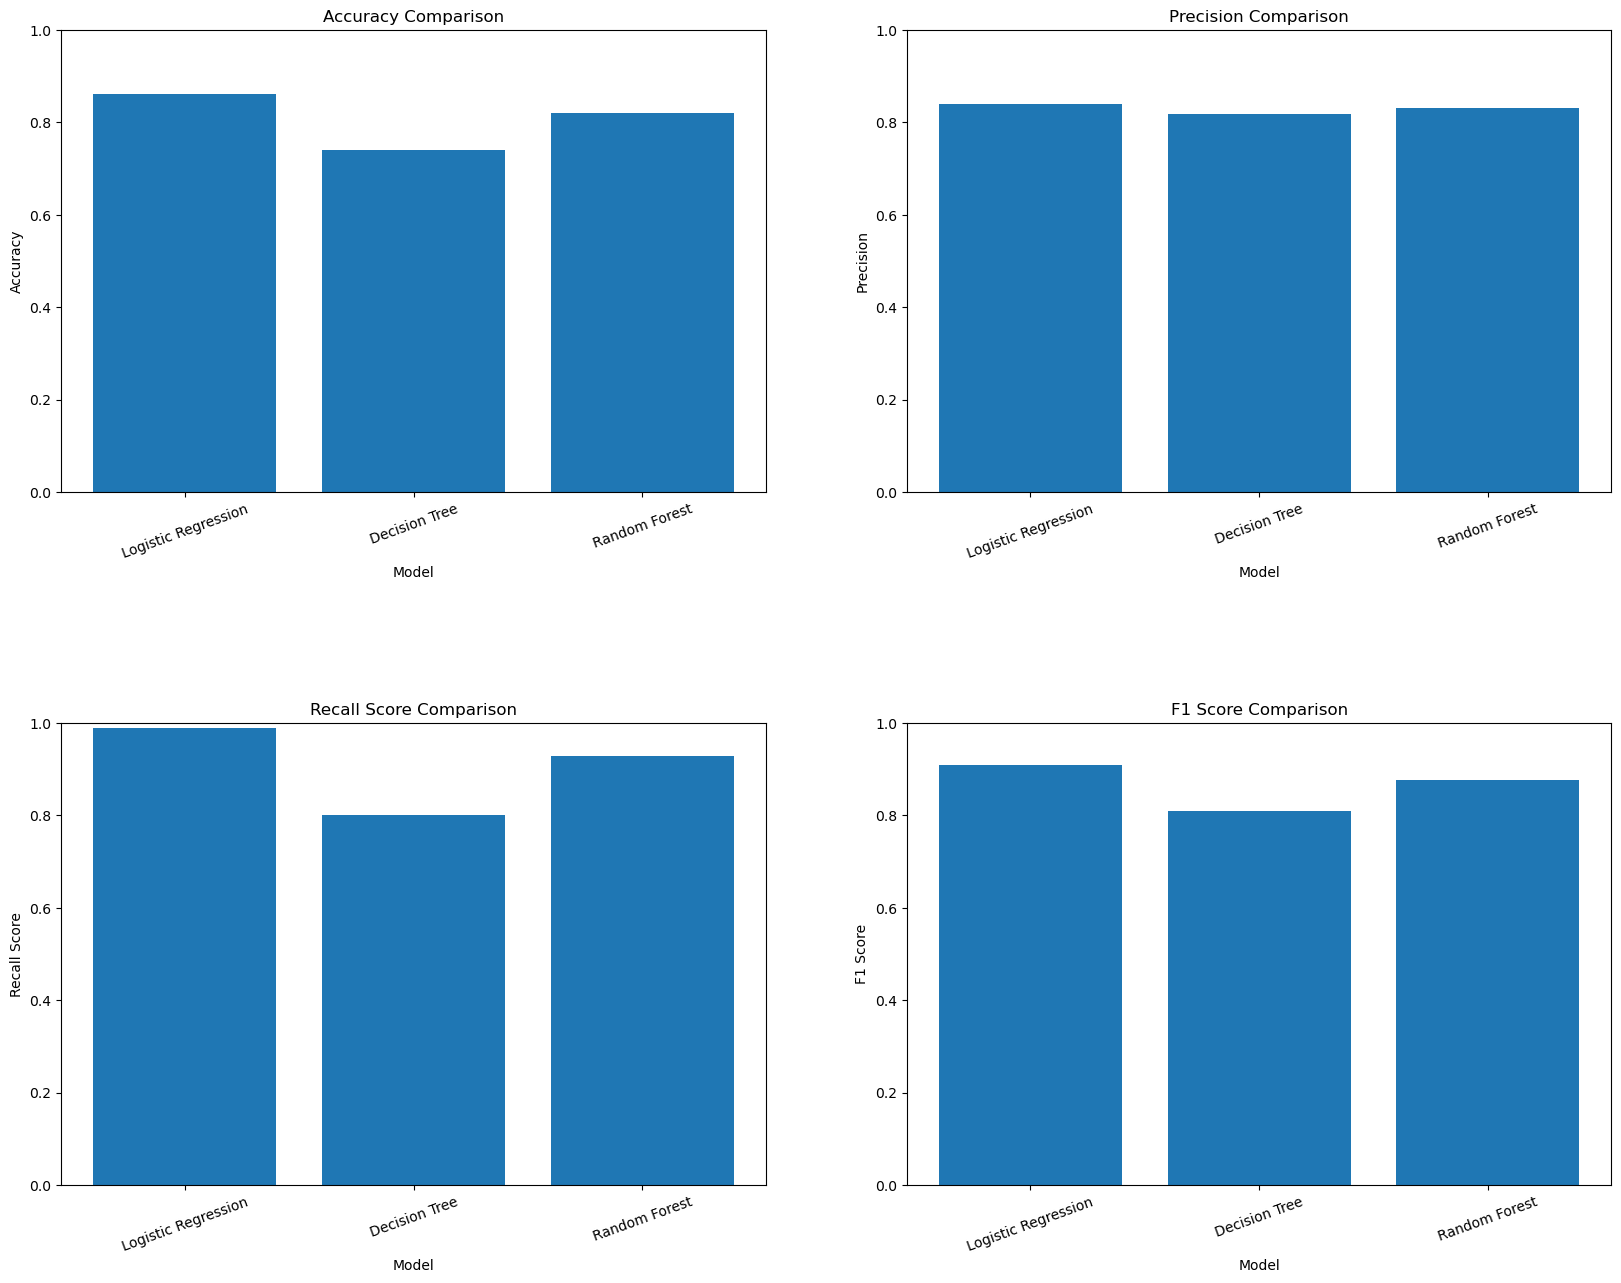

In [266]:
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
plt.bar(
    results["Model"],
    results["Accuracy"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplot(2,2,2)
plt.bar(
    results["Model"],
    results["Precision"]
)
plt.title("Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplots_adjust(hspace=0.5)

plt.subplot(2,2,3)
plt.bar(
    results["Model"],
    results["Recall Score"]
)
plt.title("Recall Score Comparison")
plt.xlabel("Model")
plt.ylabel("Recall Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.subplot(2,2,4)
plt.bar(
    results["Model"],
    results["F1 Score"]
)
plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.show()